# SSB Hilbert FIR Filter Design

Designs a complex-valued FIR filter that passes one sideband and rejects the other.

## Method

1. Design an optimal equiripple (Remez/Parks-McClellan) real lowpass FIR centered at DC.
2. Modulate it by $j^n$ to shift the passband to $[0, f_\mathrm{s}/2]$, producing a complex analytic filter.
3. Apply the filter's real part to the audio signal to get $I(n)$ and the imaginary part to get $Q(n)$.
4. The complex output $I + jQ$ is the analytic signal; its real part is USB, negated imaginary part is LSB.

Reference: [DSPrelated — Comparison of Optimal Chebyshev FIR Designs](https://www.dsprelated.com/freebooks/sasp/Comparison_Optimal_Chebyshev_FIR_I.html)

## Compact coefficient representation

Because $j^n$ is purely real on even indices and purely imaginary on odd indices, every other
tap of the analytic filter is structurally zero.  Floating-point arithmetic leaves tiny residuals
in those positions, so they are forced to exactly zero and then stripped out:

- **`SSB_REAL_COEFFS`** — 129 values: `full_filter[0, 2, 4, …, 256]`
- **`SSB_IMAG_COEFFS`** — 128 values: `full_filter[1, 3, 5, …, 255]`

Both paths share a single 257-sample shift register.  The I path multiplies every even-indexed
entry; the Q path multiplies every odd-indexed entry — roughly halving the multiply count.

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

## Design parameters

In [2]:
FS = 20_000   # DSP sample rate [Hz] — must match DSP_RATE_HZ in src/config.rs
FN = FS / 2   # Nyquist frequency [Hz]

M  = 257      # Number of filter taps (odd → symmetric, linear phase)

F1 = 530      # Lower passband edge [Hz] (removes carrier rumble)
F2 = FN - F1  # Upper passband edge [Hz] (mirror of F1 around Nyquist)

## Filter design

The Remez algorithm designs an equiripple real lowpass in the band $[0, (f_2 − f_\mathrm{s}/4)]$. Complex modulation by $j^n$ shifts the passband
to $[f_1, f_2]$ (upper sideband) centered on $f_\mathrm{s}/4 = 5 kHz$.

In [3]:
# Real lowpass prototype (Remez equiripple)
hrm = signal.remez(
    M,
    np.array([0, (F2 - FS / 4) / FN, 0.5, 1]) / 2,
    [1, 0],
    weight=[1, 10],
)

# Complex modulation: shift lowpass → analytic SSB filter
hh = hrm * 1j ** np.arange(M)

# Zero out entries that are structurally zero to eliminate floating-point residuals.
# j^n is purely real on even indices and purely imaginary on odd indices, so:
#   hh_real is non-zero only at even indices  (0, 2, 4, …)
#   hh_imag is non-zero only at odd  indices  (1, 3, 5, …)
hh_real_full = np.real(hh).astype(np.float32)
hh_imag_full = np.imag(hh).astype(np.float32)
hh_real_full[1::2] = 0.0   # force odd  positions to exact zero
hh_imag_full[0::2] = 0.0   # force even positions to exact zero

# Compact: keep only the non-zero half of each array.
# real: indices 0, 2, …, M-1  →  (M+1)//2 values
# imag: indices 1, 3, …, M-2  →  M//2     values
hh_real_compact = hh_real_full[0::2]   # length (M+1)//2 = 129
hh_imag_compact = hh_imag_full[1::2]   # length M//2     = 128

print(f'Filter taps      : {M}')
print(f'Passband         : {F1} – {int(F2)} Hz')
print(f'Real compact taps: {len(hh_real_compact)}  (even-indexed, stride-2 FIR)')
print(f'Imag compact taps: {len(hh_imag_compact)}  (odd-indexed,  stride-2 FIR)')

Filter taps      : 257
Passband         : 530 – 9470 Hz
Real compact taps: 129  (even-indexed, stride-2 FIR)
Imag compact taps: 128  (odd-indexed,  stride-2 FIR)


## Impulse response

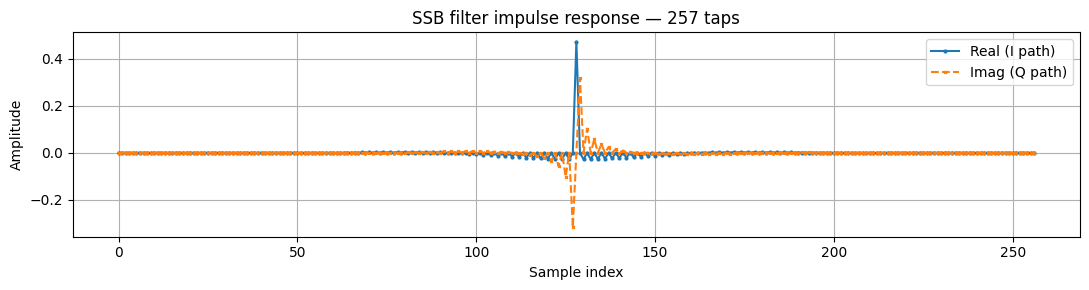

In [4]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(hh_real_full, label='Real (I path)', linestyle='-',  marker='o', markersize=2)
ax.plot(hh_imag_full, label='Imag (Q path)', linestyle='--', marker='x', markersize=2)
ax.set_title(f'SSB filter impulse response — {M} taps')
ax.set_xlabel('Sample index')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## Frequency response

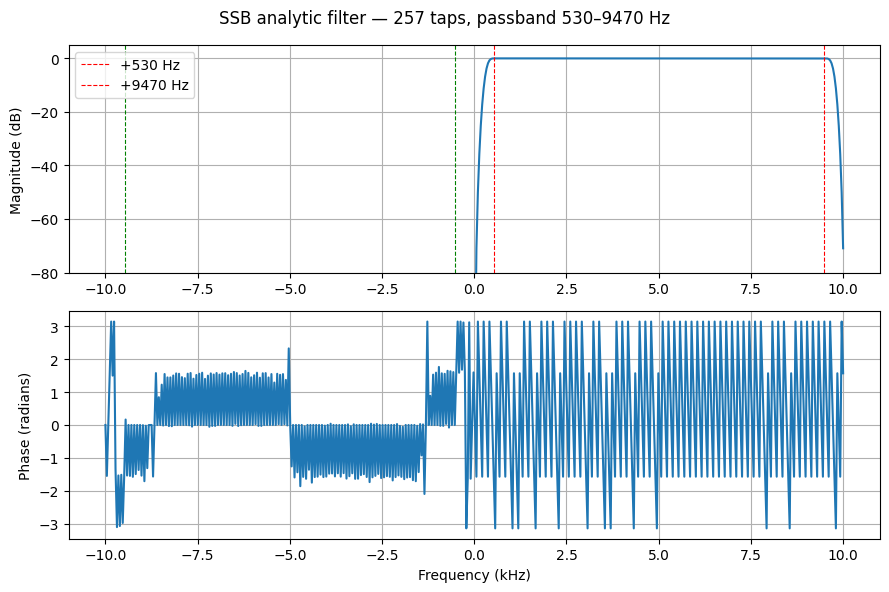

In [5]:
w, Hh = signal.freqz(hh_real_full + 1j * hh_imag_full, whole=True, fs=FS)
w_shifted = np.linspace(-FS / 2, FS / 2, len(w))
H_shifted = np.fft.fftshift(Hh)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
fig.suptitle(f'SSB analytic filter — {M} taps, passband {F1}–{int(F2)} Hz')

ax1.plot(w_shifted / 1e3, 20 * np.log10(np.abs(H_shifted) + 1e-12))
ax1.axvline( F1 / 1e3, color='r', ls='--', lw=0.8, label=f'+{F1} Hz')
ax1.axvline( F2 / 1e3, color='r', ls='--', lw=0.8, label=f'+{int(F2)} Hz')
ax1.axvline(-F1 / 1e3, color='g', ls='--', lw=0.8)
ax1.axvline(-F2 / 1e3, color='g', ls='--', lw=0.8)
ax1.set_ylabel('Magnitude (dB)')
ax1.set_ylim(-80, 5)
ax1.grid()
ax1.legend()

ax2.plot(w_shifted / 1e3, np.angle(H_shifted))
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Phase (radians)')
ax2.grid()

plt.tight_layout()
plt.show()

## Rust code generation

One interleaved `f32` array is generated for use with `arm_fir_ssb_f32`:

| Constant | Length | Layout |
|---|---|---|
| `SSB_COEFFS_INTERLEAVED` | 257 | `[real[0], imag[0], real[1], imag[1], …, real[127], imag[127], real[128]]` |

The C function `arm_fir_ssb_f32` uses an `arm_fir_instance_f32` with `numTaps = 257` and this
interleaved coefficient array.  On each output sample, it accumulates pairs: even-indexed
coefficients × even-indexed state samples → I output; odd-indexed coefficients × odd-indexed
state samples → Q output.  Both outputs share a single 257-sample state buffer (numTaps+blockSize−1).

In [ ]:
M = len(hh_real_compact) + len(hh_imag_compact)  # 257

# Interleave: [real[0], imag[0], real[1], imag[1], ..., real[127], imag[127], real[128]]
interleaved = np.zeros(M, dtype=np.float32)
interleaved[0::2] = hh_real_compact
interleaved[1::2] = hh_imag_compact

def fmt_f32_array(name, size_const, values, comment):
    rows = []
    for i in range(0, len(values), 4):
        chunk = values[i:i+4]
        rows.append('    ' + ',  '.join(f'{float(v):.10e}' for v in chunk) + ',')
    body = '\n'.join(rows)
    return (
        f'/// {comment}\n'
        f'#[rustfmt::skip]\n'
        f'pub const {name}: [f32; {size_const}] = [\n'
        f'{body}\n'
        f'];'
    )

rust = '\n\n'.join([
    f'/// Total number of taps in the SSB analytic FIR (state buffer length for arm_fir_ssb_f32).',
    f'pub const SSB_FILTER_TAPS: usize = {M};',
    fmt_f32_array(
        'SSB_COEFFS_INTERLEAVED', 'SSB_FILTER_TAPS', interleaved,
        f'Interleaved I/Q coefficients for arm_fir_ssb_f32.\n'
        f'/// Layout: [real[0], imag[0], real[1], imag[1], ..., real[127], imag[127], real[128]]\n'
        f'/// Even indices → I path, odd indices → Q path.\n'
        f'/// Passband {F1}–{int(F2)} Hz at {FS//1000} kHz, {M}-tap Remez equiripple.',
    ),
])

print(rust)